In [ ]:
# 전이학습에 대해서 알아보아요!
# 당연히 전이학습을 하려면 Pretrained Network이 있어야 해요!
# 이미 누군가에 의해서 만들어진(학습된) CNN모델이 있어야 해요!
# 이런 Pretrained Network은 그 종류가 상당히 많아요!
# 그 중 대표적인 모델은 VGG16, VGG19(학습용) , MS의 Resnet, Google의 Inception
# mobilenet(모델의 정확도는 낮지만 속도가 빠르고 가벼워요), EfficientNet(성능이 좋아요)
# 별의 별... model들이 있어요!

# Pretrained Network(CNN) 모델에서 우리가 사용할 수 있는 부분은
# 특징 추출부분이예요! 이 부분을 통해서 개와 고양이의 특징을 추출하고 
# 머신러닝에서 배운 학습기(classifier)를 이용해서 머신러닝을 구현하면 되요!

# 결국 우리가 재 사용하는 layer는 Conv2D, MaxPooling2D 예요!
# Conv2D가 여러개 있을거고 MaxPooling2D도 여러개 있겠죠.
# 하위 convolution layer는 입력데이터의 국소적인 특징을 추출(질감, 선의 형태)
# 상위 convolution layer는 입력데이터의 형태적인 특징을 추출(눈, 코와 같은)

# 원래 다른 이미지(imagenet과 같은)로 만든 filter지만 우리의 개와 고양이의 특징으
# 추출하는데도 잘 사용할 수 있어요! => 그래서 가져다 쓰는데 문제가 없어요!

In [8]:
# VGG16은 tensorflow keras안에서 제공되요
# 진짜 모델이 keras안에 포함된건 아니구요. keras를 이용하면 쉽게
# 다운로드 받을 수 있어요!
from tensorflow.keras.applications import VGG16

model_base = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(150,150,3))

model_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [ ]:
# 우리의 데이터를 model_base에 통과시켜서 그 결과인
# feature map을 ndarray에 저장할꺼예요!

# 그런다음에 이 ndarray를 이용해서 classifier에 입력으로 넣어서
# 학습할꺼예요!

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

model_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150,150,3))

base_dir = './data/cat_dog_small'
train_dir = os.path.join(base_dir,'train')  # ./data/cat_dog_small/train
validation_dir = os.path.join(base_dir,'validation')
test_dir = os.path.join(base_dir,'test')

datagen = ImageDataGenerator(rescale=1/255)
batch_size = 20

# 특정 폴더안에서 이미지 파일을 읽어서
# 해당 이미지의 픽셀을 추출해서 리턴하는게 아니라
# 이 이미지의 특징을 뽑고 그 특징 이미지의 픽셀데이터를
# 리턴하는 함수.
def extract_feature(directory, sample_count):
    # 입력이미지의 특징을 추출해서 ndarray로 리턴
    features = np.zeros(shape=(sample_count,4,4,512))
    labels = np.zeros(shape=(sample_count,))

    generator = datagen.flow_from_directory(
        directory,
        classes=['cats', 'dogs'],
        target_size=(150,150),
        batch_size=batch_size,
        class_mode='binary'
    )

    i = 0
    for x_data_batch, t_data_batch in generator:
        feature_batch = model_base.predict(x_data_batch)
        features[i*batch_size:(i+1)*batch_size] = feature_batch
        labels[i*batch_size:(i+1)*batch_size] = t_data_batch
        i += 1
        if i*batch_size >= sample_count:
            break;

    return features, labels

train_features, train_labels = extract_feature(train_dir,2000)
validation_features, validation_labels = extract_feature(validation_dir,1000)
test_features, test_labels = extract_feature(test_dir,1000)

In [16]:
# train_features(4차원), train_labels(1차원)
# validation_features, validation_labels
# test_features, test_labels
x_data_train = train_features.reshape(2000,4*4*512)
t_data_train = train_labels.reshape(-1,1)

x_data_validation = validation_features.reshape(1000,4*4*512)
t_data_validation = validation_labels.reshape(-1,1)

x_data_test = test_features.reshape(1000,4*4*512)
t_data_test = test_labels.reshape(-1,1)

In [20]:
# classifier구현

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(units=256,
                activation='relu',
                input_shape=(4*4*512,)))
model.add(Dropout(rate=0.5))
model.add(Dense(units=1,
               activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy'])

In [21]:
history = model.fit(x_data_train,
                   t_data_train,
                   epochs=30,
                   batch_size=20,
                   validation_data=(x_data_validation, t_data_validation),
                   verbose=1)

Epoch 1/30


2025-04-25 16:45:23.127287: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-04-25 16:45:23.177550: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f7a6ee72f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-25 16:45:23.177609: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2025-04-25 16:45:23.204268: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-25 16:45:23.434365: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 [==============================] - 1s 5ms/step - loss: 0.4620 - accuracy: 0.7765 - val_loss: 0.3550 - val_accuracy: 0.8280
Epoch 2/30
100/100 [==============================] - 0s 4ms/step - loss: 0.2803 - accuracy: 0.8840 - val_loss: 0.2642 - val_accuracy: 0.8910
Epoch 3/30
100/100 [==============================] - 0s 4ms/step - loss: 0.2251 - accuracy: 0.9160 - val_loss: 0.2426 - val_accuracy: 0.9060
Epoch 4/30
100/100 [==============================] - 0s 4ms/step - loss: 0.1709 - accuracy: 0.9415 - val_loss: 0.2465 - val_accuracy: 0.9030
Epoch 5/30
100/100 [==============================] - 0s 3ms/step - loss: 0.1585 - accuracy: 0.9430 - val_loss: 0.2598 - val_accuracy: 0.8980
Epoch 6/30
100/100 [==============================] - 0s 3ms/step - loss: 0.1420 - accuracy: 0.9520 - val_loss: 0.2373 - val_accuracy: 0.9050
Epoch 7/30
100/100 [==============================] - 0s 3ms/step - loss: 0.1207 - accuracy: 0.9590 - val_loss: 0.2408 - val_accuracy: 0.8970
Epoch 8/30
100/10

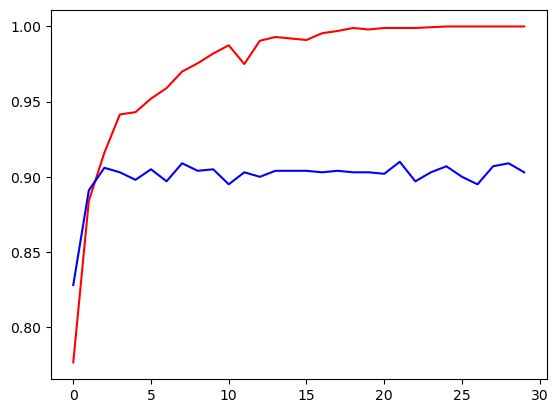

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')

plt.show()